# ANLP Assignment: Sentiment Classification

In this assignment, you will be investigating NLP methods for distinguishing positive and negative reviews written about movies.

For assessment, you are expected to complete and submit this notebook file.  When answers require code, you may import and use library functions (unless explicitly told otherwise).  All of your own code should be included in the notebook rather than imported from elsewhere.  Written answers should also be included in the notebook.  You should insert as many extra cells as you want and change the type between code and markdown as appropriate.

In order to avoid misconduct, you should not talk about the assignment questions with your peers.  If you are not sure what a question is asking you to do or have any other questions, please ask me or one of the Teaching Assistants.

Marking guidelines are provided as a separate document.

The first few cells contain code to set-up the assignment and bring in some data.   In order to provide unique datasets for analysis by different students, you must enter your candidate number in the following cell.  Otherwise do not change the code in these cells.

In [1131]:
candidateno = 291745 #this MUST be updated to your candidate number so that you get a unique data sample


In [750]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [908]:
#do not change the code in this cell
#preliminary imports

#set up nltk
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('movie_reviews')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.corpus import movie_reviews

#for setting up training and testing data
import random

#useful other tools
import re
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from itertools import zip_longest
from nltk.probability import FreqDist
from nltk.classify.api import ClassifierI


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\askar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\askar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\askar\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


In [752]:
#do not change the code in this cell
def split_data(data, ratio=0.7): # when the second argument is not given, it defaults to 0.7
    """
    Given corpus generator and ratio:
     - partitions the corpus into training data and test data, where the proportion in train is ratio,

    :param data: A corpus generator.
    :param ratio: The proportion of training documents (default 0.7)
    :return: a pair (tuple) of lists where the first element of the
            pair is a list of the training data and the second is a list of the test data.
    """

    data = list(data)
    n = len(data)
    train_indices = random.sample(range(n), int(n * ratio))
    test_indices = list(set(range(n)) - set(train_indices))
    train = [data[i] for i in train_indices]
    test = [data[i] for i in test_indices]
    return (train, test)


def get_train_test_data():

    #get ids of positive and negative movie reviews
    pos_review_ids=movie_reviews.fileids('pos')
    neg_review_ids=movie_reviews.fileids('neg')

    #split positive and negative data into training and testing sets
    pos_train_ids, pos_test_ids = split_data(pos_review_ids)
    neg_train_ids, neg_test_ids = split_data(neg_review_ids)
    #add labels to the data and concatenate
    training = [(movie_reviews.words(f),'pos') for f in pos_train_ids]+[(movie_reviews.words(f),'neg') for f in neg_train_ids]
    testing = [(movie_reviews.words(f),'pos') for f in pos_test_ids]+[(movie_reviews.words(f),'neg') for f in neg_test_ids]

    return training, testing

When you have run the cell below, your unique training and testing samples will be stored in `training_data` and `testing_data`

In [1132]:
#do not change the code in this cell
random.seed(candidateno)
training_data,testing_data=get_train_test_data()
print("The amount of training data is {}".format(len(training_data)))
print("The amount of testing data is {}".format(len(testing_data)))
print("The representation of a single data item is below")
print(training_data[0])

The amount of training data is 1400
The amount of testing data is 600
The representation of a single data item is below
(['on', 'seeing', 'the', 'outrageous', 'previews', ...], 'pos')


In [754]:
for (wordlist,label) in training_data:
    print(type(wordlist))

<class 'nltk.corpus.reader.util.StreamBackedCorpusView'>
<class 'nltk.corpus.reader.util.StreamBackedCorpusView'>
<class 'nltk.corpus.reader.util.StreamBackedCorpusView'>
<class 'nltk.corpus.reader.util.StreamBackedCorpusView'>
<class 'nltk.corpus.reader.util.StreamBackedCorpusView'>
<class 'nltk.corpus.reader.util.StreamBackedCorpusView'>
<class 'nltk.corpus.reader.util.StreamBackedCorpusView'>
<class 'nltk.corpus.reader.util.StreamBackedCorpusView'>
<class 'nltk.corpus.reader.util.StreamBackedCorpusView'>
<class 'nltk.corpus.reader.util.StreamBackedCorpusView'>
<class 'nltk.corpus.reader.util.StreamBackedCorpusView'>
<class 'nltk.corpus.reader.util.StreamBackedCorpusView'>
<class 'nltk.corpus.reader.util.StreamBackedCorpusView'>
<class 'nltk.corpus.reader.util.StreamBackedCorpusView'>
<class 'nltk.corpus.reader.util.StreamBackedCorpusView'>
<class 'nltk.corpus.reader.util.StreamBackedCorpusView'>
<class 'nltk.corpus.reader.util.StreamBackedCorpusView'>
<class 'nltk.corpus.reader.util

# Overview 
This report evaluates sentiment analysis techniques for movie reviews, classifying them as **Positive** or **Negative**. It compares a `word list classifier` and a `Naive Bayes classifier`. 

### Objectives: 

1. **Identifying Content Words:** 
- Generate lists of positive and negative words from the training data. 
2. **Building a Word List Classifier:** 
- Use the generated lists to classify reviews, explaining the process. 
3. **Evaluating Performance:** 
- Measure accuracy, precision, recall, and F1 score. 
- Discuss when accuracy might be a less suitable metric. 
4. **Constructing and Comparing a Naive Bayes Classifier:** 
- Develop and compare its performance with the word list classifier. 
- Analyze and discuss the results. 
5. **Experimenting with Wordlist Length:** 
- Assess the impact of wordlist length on the classifier's performance. 
- Present results with a graph and draw conclusions. 
- Recommend the most suitable classifier for future work, with justification.

## 1. Identifying Content Words:

1)  
a) **Generate** a list of 10 content words which are representative of the positive reviews in your training data.

b) **Generate** a list of 10 content words which are representative of the negative reviews in your training data.

c) **Explain** what you have done and why

[20\%]

The task involves generating lists of 10 content words that are representative of both `positive` and `negative` reviews in the training data.


### Text preprocessing

#### 1. Stop Words Integration 
Stop words are irrelevant for sentiment analysis, so need thorough filtering. The NLTK `standard_stop_words` list is limited. By merging it with `external_stop_words` from an external file, filtering out more irrelevant terms, resulting in clearer, more accurate sentiment analysis of movie reviews.

In [1133]:
# Creating a set of standard NLTK stop words
standard_stop_words = set(stopwords.words('english'))
print(f"Length of standard NLTK stopwords: {len(standard_stop_words)}")

# Reading additional stop words from an external file
with open(r"C:\Users\askar\OneDrive\ASKAR\Data Science\Sussex\Applied NLP\stop_words_english.txt", 'r', errors = 'ignore') as sw:
    external_stop_words = sw.read().splitlines() #split the file into list of lines
    print(f"Length of external stopwords: {len(external_stop_words)}")
    
# Combining the standard NLTK stop words with the external stop words  
stop_words = standard_stop_words.union(external_stop_words)


Length of standard NLTK stopwords: 179
Length of external stopwords: 851


To identify positive and negative content words, we augmented the standard stop word list with domain-specific words frequently found in the documents. 
These were categorized into: 
- **Neutral Words**: Irrelevant for sentiment analysis (e.g., "general," "details").
- **Common Movie Terms**: Words like "film" and "movie" that don't affect sentiment. 
- **Ambiguous Words**: Appearing in both positive and negative reviews (e.g., "performance," "story"). 
- **Context-Dependent Words**: Words with different meanings based on context (e.g., "hard," "kill").

In [1134]:
# Defining a custom set of stop words specific to movie reviews
custom_stopwords = {'film', 'films', 'movies',"film's", 'movie', "movie's", 'performance', 'cinema', 'scene', 'scenes', 'character',
                    'characters', 'acting', 'actor', 'director', 'story', 'cast', 'watch', 'death', 'dead','killer', 'murder', 'scream', 
                    'opinion', 'view', 'cinema', 'audience', 'general', 'final', 'details', 'actress', 'role', 'plot', 'lack', 
                    'script', 'screenplay', 'cinematography', 'soundtrack', 'visual', 'effects', 'dialogue', 'cgi', 'work','feel',
                    'lead', 'funny', 'fall', 'joke', 'fall', 'lost', 'hard','kill', 'evil', 'stupid', 'problem'}

# Combining the standard stop words with the custom stop words
stop_words = stop_words.union(custom_stopwords)

print(f"Overall length of stopwords: {len(stop_words)}")


Overall length of stopwords: 926


#### 2. Data Normalisation

Normalization ensures data is clean and uniform, transforming text into a consistent format for easier analysis. The positive and negative word lists are sourced from `positive-words.txt` and `negative-words.txt`. These curated lists help efficiently classify text as positive or negative.

In [1135]:
# Reading positive words from a file
with open(r"C:\Users\askar\OneDrive\ASKAR\Data Science\Sussex\Applied NLP\positive-words.txt", 'r', errors = 'ignore') as pw:
        pos_words = pw.read().splitlines()
        
# Reading negative words from a file      
with open(r"C:\Users\askar\OneDrive\ASKAR\Data Science\Sussex\Applied NLP\negative-words.txt", 'r', errors = 'ignore') as nw:
        neg_words = nw.read().splitlines()
        

To improve sentiment analysis, training and testing data are normalized using the `data_normalise` function. This involves **lemmatizing words and removing unwanted tokens**, refining the dataset.

The code normalizes `training_data` and `testing_data`, storing results in `normalised_training_data` and `normalised_testing_data`.


**Code Breakdown:** 

- Creates `normalised_wordlist` with lemmatized words from `list_of_words`. 
- **`lemma.lemmatize(word)`**: Lemmatizes each word to its base form. 
- **`word.isalpha()`**: Includes only alphabetic words, filtering out non-letters. 
- **`lemma.lemmatize(word)`** not in `stop_words`: Excludes stop words for relevance.

This ensures that common and irrelevant words (stop words) are removed from the list.

In [1136]:
# Importing the WordNetLemmatizer from the NLTK library
from nltk.stem import WordNetLemmatizer
lemma = WordNetLemmatizer() #Initalisation

# This function will remove unwanted tokens from a list of words
def data_normalise(list_of_words): 
    
    # Lemmatize each word in the list, ensure it contains only alphabetic characters, and is not present in the stop_words set
    normalised_wordlist = [lemma.lemmatize(word) for word in list_of_words if word.isalpha() and lemma.lemmatize(word) not in stop_words]
    
    return normalised_wordlist


The `training_data` and `testing_data` are tuples of word lists and sentiment labels (refer to code no 753). Each word list is normalized using the `data_normalise` function in a list comprehension, then stored back in their original structure.

In [1137]:
#Normalising the training data
normalised_training_data = [(data_normalise(list_of_words), sentiment) for (list_of_words, sentiment) in training_data]

#Normalising the testing data
normalised_testing_data = [(data_normalise(list_of_words), label) for (list_of_words, sentiment) in testing_data]


### Generating conetent words list

The below `find_frequent_content_words()` function identifies the most frequent content words for a specified sentiment from the `normalised_training_data`.

**Positive content words: `if sentiment == 'pos'`**
- Filters words in `normalised_data` labeled as positive **`(label == sentiment)`**.
- Selects words from the predefined list of positive words **`(pos_words)`**.
- Uses `FreqDist` to compute the frequency and returns the `top_n` most common words.

**Negative content words: `if sentiment == 'neg'`**
- Similarly, selects negative words, computes their frequency, and returns the `top_n` most common words.


In [1138]:
def find_frequent_content_words(normalised_data, sentiment, top_n = 10):
    """ 
     Finds the most frequent content words for a given sentiment. 
     
     Parameters: normalised_data (list): List of tuples containing word lists and their sentiment labels. 
     sentiment (str): The sentiment ('pos' or 'neg') for which to find common content words. 
     top_n (int): The number of top frequent words to return (default is 10). 
     
     Returns: list: A list of the most frequent content words for the given sentiment.
    """
    
    if sentiment == 'pos':
        # Extract positive words from the normalised data
        positive_reviews = [word for words, label in normalised_data if label == sentiment for word in words if word in pos_words]
        # Return the top_n most common words
        return [word for word, frequent_count in FreqDist(positive_reviews).most_common(top_n)] 
    
    if sentiment == 'neg':
        # Extract negative words from the normalised data
        negative_reviews = [word for words, label in normalised_data if label == sentiment for word in words if word in neg_words]
        # Return the top_n most common words
        return [word for word, frequent_count in FreqDist(negative_reviews).most_common(top_n)]
    

The function calls below retrieve the 10 most frequent content words from positive and negative reviews in the `normalised_training_data`. The data and sentiment are sent, and the results are stored in `pos_content_words` and `neg_content_words`, respectively.


In [1139]:
# Find the most frequent 10 content words for positive and negative sentiments
pos_content_words = find_frequent_content_words(normalised_training_data, 'pos')
neg_content_words = find_frequent_content_words(normalised_training_data, 'neg')

# Print the lists of most common content words
print(f'List of 10 content words from the positive reviews in the training data:\n{pos_content_words}\n')
print(f'List of 10 content words from the negative reviews in the training data:\n{neg_content_words}')

List of 10 content words from the positive reviews in the training data:
['good', 'great', 'love', 'fun', 'interesting', 'perfect', 'beautiful', 'pretty', 'classic', 'humor']

List of 10 content words from the negative reviews in the training data:
['bad', 'worst', 'wrong', 'boring', 'poor', 'worse', 'hell', 'waste', 'dull', 'terrible']


- The code starts by creating a list of **stop words** to remove from the reviews, like "the," "and," and "of." It also removes punctuation, numbers, and movie-specific words like "film" and "movie," which don't indicate sentiment.

- Next, it identifies words typically associated with **positive and negative sentiments** to determine the overall sentiment of a review.

- Each review's text is converted to its root form (e.g., "running" to "run") to standardize the text and facilitate analysis.

- Finally, the code identifies the **most common words** associated with positive and negative sentiments to train a model that can classify new reviews as positive or negative.


## 2. Building a Word List Classifier:

A simple word list classifier leverages predefined lists of positive and negative words `pos_content_words` and `neg_content_words` to determine the sentiment of a given document.

2)
a) **Use** the lists generated in Q1 to build a **word list classifier** which will classify reviews as being positive or negative.

b) **Explain** what you have done.

[12.5\%]


The `SimpleClassifier` class is a basic sentiment analysis model. 

- In the code below, the `classify_many` method iterates through test documents, calculating a `sentiment_score` for each.
- It checks **`if word in self._positive:`**, adding positive word frequencies to the `sentiment_score`. It also checks **`if word in self._negative:`**, subtracting negative word frequencies from the `sentiment_score`.
- The document is classified as positive if the `sentiment_score` is positive, or negative otherwise, appending the classification to a results list.


In [1140]:
class SimpleClassifier(ClassifierI): 
    def __init__(self, positive, negative): 
        # Initialize the classifier with sets of positive and negative words
        self._positive = set(positive) 
        self._negative = set(negative)

    def classify_many(self, test_data):
        # Initialize a list to store the classification results
        score_results = []
        
        for doc in test_data: 
            # Calculate the frequency distribution of words in the document
            word_freq = FreqDist(doc)
            sentiment_score = 0
            
            for word, freq_count in word_freq.items():
                # Increase score for positive words
                if word in self._positive:
                    sentiment_score += freq_count
                # Decrease score for negative words
                if word in self._negative:
                    sentiment_score -= freq_count
            
            # Append 'neg' if score is negative, otherwise 'pos'
            score_results.append("neg" if sentiment_score < 0 else "pos")
            
        # Return the list of classification results    
        return score_results

The code initializes `SimpleClassifier` with `pos_content_words` and `neg_content_words` as `wordlist_classifier`.

`**zip(*normalised_testing_data)**` separates `test_data` and `original_labels` from `normalised_testing_data`.

`**classifier.classify_many(test_data)**` classifies the test data, storing predictions in `predicted_labels`. Predictions and actual sentiments are displayed in a dataframe for comparison.


In [1141]:
# Initialize the SimpleClassifier with the positive and negative content words
wordlist_classifier = SimpleClassifier(pos_content_words, neg_content_words)

# Unpacking the test data and original labels from the normalised testing data
test_data, original_labels = zip(*normalised_testing_data) 

# Classify the test data using the SimpleClassifier
predicted_labels = wordlist_classifier.classify_many(test_data)

# Create a DataFrame to compare original and predicted labels
wordlist_classifier_df = pd.DataFrame({'Original Labels': original_labels, 'Predicted Labels': predicted_labels})

display(wordlist_classifier_df) # Display the DataFrame

,Original Labels,Predicted Labels
0,neg,neg
1,neg,pos
2,neg,pos
3,neg,pos
4,neg,pos
...,...,...
595,neg,pos
596,neg,pos
597,neg,pos
598,neg,pos


`SimpleClassifier` uses predefined positive and negative words to determine sentiment polarity. For each document, it calculates a sentiment score based on the presence of these words: positive scores indicate positive sentiment and negative scores indicate negative sentiment. 

The classifier calculates sentiment scores from word frequencies and assigns sentiment labels. The `classify_many` function applies this scoring to multiple texts, generating predicted sentiment labels, which are then compared to actual labels to evaluate performance.


## 3. Evaluating Classifier Performance:

3)
a) **Calculate** the accuracy, precision, recall and F1 score of your classifier.

b) Is it reasonable to evaluate the classifier in terms of its accuracy?  **Explain** your answer and give a counter-example (a scenario where it would / would not be reasonable to evaluate the classifier in terms of its accuracy).

[20\%]

This code snippet creates and visualizes a confusion matrix to assess the performance of a text sentiment classifier.

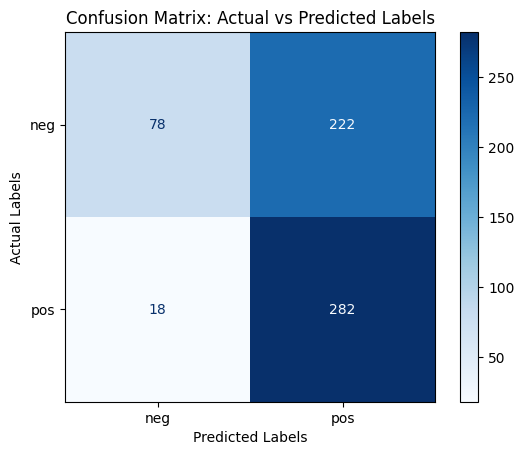

In [1142]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrix to evaluate the accuracy of a classification
cm = confusion_matrix(actual_labels, predicted_labels)

# ConfusionMatrixDisplay object for visualizing the confusion matrix
cmd = ConfusionMatrixDisplay(cm, display_labels = ['neg', 'pos'])

cmd.plot(cmap = 'Blues') # Plot the confusion matrix with a specified color map

# Add a title,and label for x-axis and y-axis to the plot
plt.title('Confusion Matrix: Actual vs Predicted Labels')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')

plt.show() #display the plot

- **True Negatives (TN): 78** - Correctly predicted negative instances.
- **False Positives (FP): 222** - Incorrectly predicted positive instances.
- **False Negatives (FN): 18** - Incorrectly predicted negative instances.
- **True Positives (TP): 282** - Correctly predicted positive instances.


The `classifier_evaluate()` class evaluates a classification model using predicted and original labels from test data and sentiment labels "pos" and "neg".

It extracts True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN) from the confusion matrix and stores them as class attributes.


**`accuracy()`**: Calculates overall accuracy by iterating through predicted and original labels, counting correct predictions, and dividing by the total data points.

**`precision()`**: Calculates precision for the positive class. Checks for zero denominator and returns TP / (TP + FP).

**`recall()`**: Calculates recall for the positive class. Checks for zero denominator and returns TP / (TP + FN).

**`f1_score()`**: Computes the F1-score, the harmonic mean of precision and recall, using **(2 * precision * recall) / (precision + recall)**, handling division by zero.


In [1143]:
class classifier_evaluate:
    
    def __init__(self, conf_mat, sentiments = ("pos", "neg")):  
        # Initialize the class with predicted and original labels
        (self.s1, self.s2) = sentiments 
        
        # Compute the confusion matrix
        cm = conf_mat
        
        # Extract True Positives, True Negatives, False Positives, and False Negatives from the confusion matrix
        self.TP = cm[1, 1]
        self.TN = cm[0, 0]
        self.FP = cm[0, 1]
        self.FN = cm[1, 0]
    
    
    def accuracy(self):

        # Calculate the accuracy of the classifier
        accuracy = (self.TP + self.TN) / (self.TP + self.TN + self.FP + self.FN)
        return accuracy
                
    def precision(self):
        # Calculate the precision of the classifier
        if self.TP + self.FP != 0:
            # Precision is the ratio of true positives to the sum of true positives and false positives
            return self.TP / (self.TP + self.FP)
        
        else:
            # Return 0 if the denominator is zero to avoid division by zero error
            return 0
        
    def recall(self):
        # Calculate the recall of the classifier
        if self.TP + self.FP != 0:
            # Recall is the ratio of true positives to the sum of true positives and false negatives
            return self.TP / (self.TP + self.FN)
        
        else:
            # Return 0 if the denominator is zero to avoid division by zero error
            return 0
  
    def f1_score(self):
        # Calculate the f1_score of the classifier
        p = self.precision()
        r = self.recall()
        
        # Check if the sum of precision and recall is not zero
        if p + r != 0:
            # F1 score is the harmonic mean of precision and recall
            return (2 * p * r) / (p + r)
        else:
            # Return 0 if the sum of precision and recall is zero to avoid division by zero
            return 0
        

This code snippet initialise `classifier_evaluate` class to calculate and display various performance metrics for a classification model.

In [1144]:
# Instantiate the classifier_evaluate class with with confusion matrix values
metrics = classifier_evaluate(cm)

# Calculate accuracy, precision, recall, f1_score
accuracy = metrics.accuracy() 
precision = metrics.precision()
recall = metrics.recall()
f1_score = metrics.f1_score()

#Dispaly results
print(f"Wordlist classifier Model accuracy score is {round(accuracy, 2)} and the perscentage is {round(accuracy*100, 2)}%")
print(f"Wordlist classifier Model precision score is {round(precision, 2)} and the perscentage is {round(precision*100, 2)}%")
print(f"Wordlist classifier Model recall score is {round(recall, 2)} and the perscentage is {round(recall*100, 2)}%")
print(f"Wordlist classifier Model f1 score is {round(f1_score, 2)} and the perscentage is {round(f1_score*100, 2)}%")

Wordlist classifier Model accuracy score is 0.6 and the perscentage is 60.0%
Wordlist classifier Model precision score is 0.56 and the perscentage is 55.95%
Wordlist classifier Model recall score is 0.94 and the perscentage is 94.0%
Wordlist classifier Model f1 score is 0.7 and the perscentage is 70.15%


**3b**
Evaluating a classifier by its accuracy is reasonable for balanced datasets, where classes are evenly distributed, providing a clear measure of performance. However, in imbalanced datasets or scenarios with different costs for misclassifications, accuracy can be misleading. 

For instance, in a medical diagnosis where false negatives have severe consequences, metrics like precision, recall, and F1-score are more appropriate to ensure critical errors are minimized.

## 4. Constructing a Naive Bayes Classifier

4)
a)  **Construct** a Naive Bayes classifier (e.g., from NLTK).

b)  **Compare** the performance of your word list classifier with the Naive Bayes classifier.  **Discuss** your results.

[12.5\%]

- The code iterates over `normalised_training_data` and `normalised_testing_data`, which are lists of tuples containing tokens and labels.
- For each tuple, it creates a frequency distribution for the tokens and pairs it with the label.
- The results are stored in `tain_data_freq_dist` and `test_data_freq_dist`, as lists of tuples with frequency distributions and corresponding labels.


In [1145]:
# Create frequency distributions for the training data and testing data
tain_data_freq_dist = [(FreqDist(tokens), label) for tokens, label in normalised_training_data]
test_data_freq_dist = [(FreqDist(tokens), label) for tokens, label in normalised_testing_data]


The code implements a Naive Bayes Classifier (`NBClassifier`).

- **Vocabulary:** Identifies unique words in the training data.

- **Prior Probabilities:** Calculates the proportion of documents in each class.

- **Conditional Probabilities:** Calculates the probability of each word given a class, normalizing by the total words in that class. **Laplace smoothing (add-one smoothing)** is applied to handle unseen words.
- **Calculating Posterior Probabilities:** For a document, the classifier calculates the posterior probability of each class using Bayes' theorem. This involves multiplying the prior probability by the product of the conditional probabilities of each word given that class.
- **Selecting the Class:** The class with the highest posterior probability is chosen as the predicted class.


In [1149]:
class NBClassifier(ClassifierI):
    
    def __init__(self):
        #Initializes the classifier
        pass
    
    def known_vocabulary(self,training_data):
        #Determines the known vocabulary from the training data
        known=[]
        
        for doc,label in training_data:
            known+=list(doc.keys())
        self.known= set(known)
    
    def class_priors(self,training_data):
        #Calculates the prior probability for each class.
        priors={}
        
        for (doc,label) in training_data:
            priors[label]=priors.get(label,0)+1
        total=sum(priors.values())
        
        for key,value in priors.items():
            priors[key]=value/total
        self.priors=priors
        
    def cond_probs(self,training_data): 
        #Calculates the conditional probabilities of words given a class.
        conds={}
        
        for(doc,label) in training_data:
            classcond=conds.get(label,{})
            
            for word in doc.keys():
                classcond[word]=classcond.get(word,0)+1
        
            conds[label]=classcond
    
        # Add-one smoothing to handle unseen words
        for label, classcond in conds.items():
            for word in self.known:
        
                classcond[word]=classcond.get(word,0)+1
            conds[label]=classcond
            
        for label,dist in conds.items():
            total=sum(dist.values())
            conds[label]={key:value/total for (key,value) in dist.items()}
        
        self.conds=conds
    
    #Trains the Naive Bayes classifier.
    def train(self,training_data):
        self.known_vocabulary(training_data)
        self.class_priors(training_data)
        self.cond_probs(training_data)
    
    def nb_classify(self,doc):
        #Classifies a new document.
        doc_probs={key:math.log(value) for (key,value) in self.priors.items()}
        
        for word in doc.keys():
            if word in self.known:
                doc_probs={classlabel:sofar+math.log(self.conds[classlabel].get(word,0)) for (classlabel,sofar) in doc_probs.items()}

        highprob=max(doc_probs.values())
        classes=[c for c in doc_probs.keys() if doc_probs[c]==highprob]
        
        return random.choice(classes)

**`nb_classifier.train(tain_data_freq_dist):`** Trains the classifier using the frequency distributions of the training data, calculating known vocabulary, prior probabilities, and conditional probabilities.

**`nb_predicted_labels = [nb_classifier.NB_classify(doc) for (doc, label) in test_data_freq_dist]:`**
    Uses the trained classifier to classify each document in the test data, calling `NB_classify` to predict labels, and stores the predictions in `nb_predicted_labels`.


In [1150]:
# Initialize the Naive Bayes classifier
nb_classifier = NBClassifier()

# Train the classifier using the training data frequency distributions
nb_classifier.train(tain_data_freq_dist)

# Classify the test data using the trained Naive Bayes classifier
nb_predicted_labels = [nb_classifier.nb_classify(doc) for (doc, label) in test_data_freq_dist]

# Create a DataFrame to compare original and predicted labels
nb_classifier_df = pd.DataFrame({'Original Labels': original_labels, 'Predicted Labels': nb_predicted_labels})

display(nb_classifier_df) # Display the DataFrame

,Original Labels,Predicted Labels
0,neg,pos
1,neg,neg
2,neg,neg
3,neg,pos
4,neg,pos
...,...,...
595,neg,neg
596,neg,neg
597,neg,neg
598,neg,neg


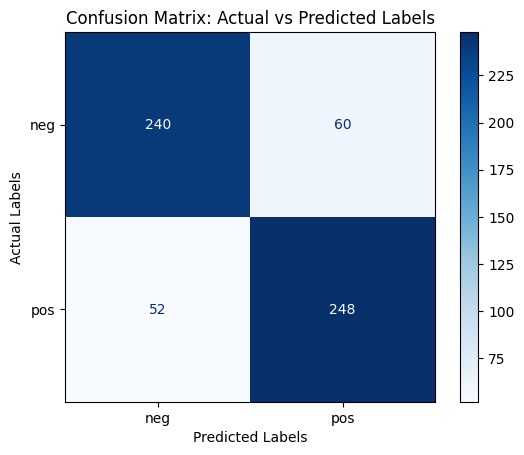

In [1126]:
# Confusion matrix to evaluate the accuracy of a classification
nb_cm = confusion_matrix(actual_labels, nb_predicted_labels)

# ConfusionMatrixDisplay object for visualizing the confusion matrix
nb_cmd = ConfusionMatrixDisplay(nb_cm, display_labels = ['neg', 'pos'])

nb_cmd.plot(cmap ='Blues') # Plot the confusion matrix with a specified color map

# Add a title,and label for x-axis and y-axis to the plot
plt.title('Confusion Matrix: Actual vs Predicted Labels')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')

plt.show() #display the plot


In [1151]:
# Instantiate the classifier_evaluate class with confusion matrix values
nb_metrics = classifier_evaluate(nb_cm)

# Calculate accuracy, precision, recall, f1_score
nb_accuracy = nb_metrics.accuracy() 
nb_precision = nb_metrics.precision()
nb_recall = nb_metrics.recall()
nb_f1_score = nb_metrics.f1_score()

#Dispaly results
print(f"Naive Bayes classifier Model accuracy score is {round(nb_accuracy, 2)} and the perscentage is {round(nb_accuracy*100, 2)}%")
print(f"Naive Bayes classifier Model precision score is {round(nb_precision, 2)} and the perscentage is {round(nb_precision*100, 2)}%")
print(f"Naive Bayes classifier Model recall score is {round(nb_recall, 2)} and the perscentage is {round(nb_recall*100, 2)}%")
print(f"Naive Bayes classifier Model f1 score is {round(nb_f1_score, 2)} and the perscentage is {round(nb_f1_score*100, 2)}%")

Naive Bayes classifier Model accuracy score is 0.81 and the perscentage is 81.33%
Naive Bayes classifier Model precision score is 0.81 and the perscentage is 80.52%
Naive Bayes classifier Model recall score is 0.83 and the perscentage is 82.67%
Naive Bayes classifier Model f1 score is 0.82 and the perscentage is 81.58%


**4b**
The Naive Bayes classifier outperforms the word list classifier with an accuracy of **81.33%**, precision of 80.52%, recall of 82.67%, and F1 score of 81.58%. The word list classifier shows an accuracy of **60.0%**, precision of 55.95%, recall of 94.0%, and F1 score of 70.15%. While the Naive Bayes classifier offers a balanced and reliable performance, the word list classifier excels in recall but suffers in precision, leading to more false positives. This highlights the Naive Bayes classifier’s overall robustness in sentiment analysis.

## 5. Experimenting with Wordlist Length:

5)
a) Design and **carry out an experiment** into the impact of the **length of the wordlists** on the wordlist classifier.  Make sure you **describe** design decisions in your experiment, include a **graph** of your results and **discuss** your conclusions.

b) Would you **recommend** a wordlist classifier or a Naive Bayes classifier for future work in this area?  **Justify** your answer.

[25\%]


**`__init__()`**: Initializes the classifier with the number of top frequent content words (`self.top_n`).

**`train()`**: Calls `find_frequent_content_words()` to find top frequent positive and negative sentiment words, storing them in `self._positive` and `self._negative`.

**`classify_many()`**: 
- Initializes an empty list (`score_results`) for classification results. 
- Iterates over each document in `test_data`, calculating word frequency (`word_freq`).
- Updates sentiment score by increasing it for words in `self._positive` and decreasing it for words in `self._negative`.
- Appends 'neg' if the sentiment score is negative, otherwise 'pos', to `score_results`, and returns it.


In [1152]:
class VariableLength_WordListClassifier(ClassifierI): 
    def __init__(self, top_n): 
        # Initialize the classifier with sets of positive and negative words
        self.top_n = top_n
        
    def train(self, training_data):
                
        self._positive = find_frequent_content_words(training_data,'pos',self.top_n)
        self._negative = find_frequent_content_words(training_data,'neg',self.top_n)

    def classify_many(self, test_data):
        # Initialize a list to store the classification results
        score_results = []
        
        for doc in test_data: 
            # Calculate the frequency distribution of words in the document
            word_freq = FreqDist(doc)
            sentiment_score = 0
            
            for word, freq_count in word_freq.items():
                # Increase score for positive words
                if word in self._positive:
                    sentiment_score += freq_count
                # Decrease score for negative words
                if word in self._negative:
                    sentiment_score -= freq_count
            
            # Append 'neg' if score is negative, otherwise 'pos'
            score_results.append("neg" if sentiment_score < 0 else "pos")
            
        # Return the list of classification results    
        return score_results

- `top_n_values = sorted(random.sample(range(29, 174), 5))`: Generates 5 sorted random values within the range of 29 to 174, representing different word list sizes for the classifier.
- `acc_results = {}`: Initializes an empty dictionary for accuracy results.

For each `top_n` value:
  - **Train Classifier:**
    - `vl_classifier = VariableLength_WordListClassifier(top_n)`: Initializes the classifier with `top_n`.
    - `vl_classifier.train(normalised_training_data)`: Trains using the normalised training data.

  - **Classify Test Data:**
    - `vl_classifier.classify_many(test_data)`: Classifies test data and stores `topn_predicted_labels`.

  - **Calculate Confusion Matrix:**
    - `confusion_matrix(actual_labels, topn_predicted_labels)`: Calculates confusion matrix and extracts TP, TN, FP, and FN.

  - **Calculate Accuracy:**
    - `accuracy = (TP + TN) / (TP + TN + FP + FN)`: Calculates accuracy and stores the rounded value in `acc_results` with `top_n` as the key (`acc_results[top_n] = round(accuracy, 2)`).


In [1153]:
# Here, we generate 5 different random values based on my candidate number 291745
random.seed(42)
top_n_values = sorted(random.sample(range(29, 174), 5)) #candno:291745

# Dictionary to store the results for each top_n value
acc_results = {}

for top_n in top_n_values:
    # Initialize and train the classifier with the current top_n value
    vl_classifier = VariableLength_WordListClassifier(top_n)
    vl_classifier.train(normalised_training_data)
    
    # Classify the test data
    topn_predicted_labels = vl_classifier.classify_many(test_data)
    
    # Calculate confusion matrix
    cm = confusion_matrix(actual_labels, topn_predicted_labels)
    
    # Calculate accuracy manually: (TP + TN) / (TP + TN + FP + FN)
    TP = cm[0, 0]  # True Positive
    TN = cm[1, 1]  # True Negative
    FP = cm[0, 1]  # False Positive
    FN = cm[1, 0]  # False Negative
    
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    
    # Store the accuracy in the results dictionary
    acc_results[top_n] = round(accuracy, 2)
    

Converts the `acc_results` dictionary into a DataFrame.

In [1154]:
# Create a DataFrame from the dictionary
wordlist_length_accuracy_df = pd.DataFrame.from_dict(acc_results, orient='index', columns=['Accuracy'])
wordlist_length_accuracy_df.index.name = 'Word List Length'

#display results
display(wordlist_length_accuracy_df)

,Accuracy
Word List Length,
35,0.62
57,0.63
86,0.64
91,0.65
99,0.65


Plots the accuracy values against the top N values.

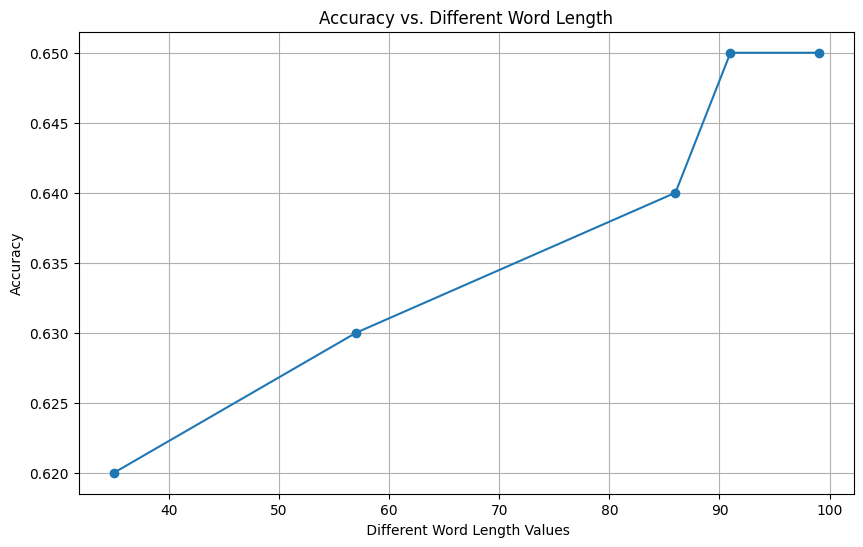

In [1156]:
# Create a figure with specified dimensions
plt.figure(figsize = (10, 6))

#   - x-axis: Top N values (keys of the dictionary)
#   - y-axis: Accuracy values (values of the dictionary)
plt.plot(list(acc_results.keys()), list(acc_results.values()), marker = 'o', linestyle = '-')

# Add a title,and label for x-axis and y-axis to the plot
plt.xlabel(' Different Word Length Values')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Different Word Length')

#display results
plt.grid(True)
plt.show()

- The accuracy shows a **positive trend with the increase in the length** of the word lists. For example, moving from 35 to 99 words, the accuracy increases from 0.62 to 0.65.
- While the accuracy improves with longer word lists, the rate of improvement diminishes as the length increases. The accuracy increase from 86 to 99 words is marginal (0.64 to 0.65), indicating that **beyond a certain point, adding more words may yield smaller gains in performance**.

**Conclusion:**
Increasing the length of word lists in the wordlist classifier **enhances its accuracy up to a certain point**. However, after a certain threshold, the benefit of **adding more words becomes less significant**. This suggests that there is an optimal range for word list length that balances performance improvement and efficiency.

**5b**
Given the results, I would recommend using the **Naive Bayes classifier** for future work in this area.

**Justification:**
 - The Naive Bayes model has achieved an **accuracy score of 0.81**, which translates to **81.33%** for just length of 10 positive and negative words itself. This is **significantly higher** than the accuracy scores obtained from the **wordlist classifier (which ranged around 0.65)**.
 - Naive Bayes classifiers use a **probabilistic approach**, making them robust and able to **handle diverse datasets effectively**.
 - The Naive Bayes classifier naturally incorporates all features (words) and their probabilities**without being limited to a fixed number of top/common words**. This allows it to leverage more information from the dataset.
 - Naive Bayes classifiers are **computationally efficient and scalable**, handling large datasets and multiple features with ease when compared to wordlist classifier.

**Conclusion:**
While the wordlist classifier shows some potential, the Naive Bayes classifier's higher accuracy and robust, probabilistic approach make it a superior choice for sentiment analysis and similar tasks. Focusing on improving and tuning the Naive Bayes model would likely yield better performance and reliability in future projects.

In [1161]:
##This code will word count all of the markdown cells in the notebook saved at filepath

import io
from nbformat import current

#from google.colab import drive
#drive.mount('/content/drive')

filepath=r"C:\Users\askar\OneDrive\ASKAR\Data Science\Sussex\Applied NLP\Askar_291745_ANLPassignment2024.ipynb"

question_count=432

with io.open(filepath, 'r', encoding='utf-8') as f:
    nb = current.read(f, 'json')

word_count = 0
for cell in nb.worksheets[0].cells:
    if cell.cell_type == "markdown":
        word_count += len(cell['source'].replace('#', '').lstrip().split(' '))
print("Submission length is {}".format(word_count-question_count))

Submission length is 1968
